In [38]:
import numpy as np
import matplotlib.pyplot as plt

AXES = np.array([[1,0,0],[-1,0,0],[0,1,0],[0,-1,0],[0,0,1],[0,0,-1]], dtype=float)

class MusicArena3D:
    """Actions discrètes : 0 = tout droit, 1 = gauche 90°, 2 = droite 90°."""
 
    def __init__(self, room_size=15.0, beat_prob=0.10, L_target=13.0, v_min=0.4, v_max=2.2,
                 window_past=4, window_future=8, wall_horizon=6, n_samples=8, sigma=2.5, tau=1.5, lag=8, w_cover=3.0):
        self.room_size = room_size
        self.beat_prob = beat_prob
        self.L_target = L_target
        self.v_min, self.v_max = v_min, v_max                   
        self.P = window_past                 
        self.F = window_future                
        self.H = window_future                
        self.max_steps = 200
        self.Hwall = wall_horizon
        self.n_actions = 3
        self.M = n_samples
        self.sig = sigma
        self.tau = tau
        self.lag = lag
        self.w_cover = w_cover
        self.samp = np.linspace(-room_size, room_size, self.M)
        self.reset()
        self.state_dim = len(self._get_state())


    def _interval_gap(self, k):
        nxt = k
        while nxt < len(self.beats) and not self.beats[nxt]:
            nxt += 1
        prev = k - 1
        while prev >= 1 and not self.beats[prev]:
            prev -= 1
        if prev < 1:
            prev = 0
        return max(nxt - prev, 1)
 
    def _speed_at(self, k):
        return float(np.clip(self.L_target / self._interval_gap(k), self.v_min, self.v_max))
    
    def _perp(self):
        return AXES[np.abs(AXES @ self.d) < 0.5]
 
    def _wall_ahead(self):
        p = self.pos.copy()
        for j in range(self.Hwall):
            p = p + self.d * self._speed_at(self.current_step + 1 + j)
            if np.any(np.abs(p) > self.room_size):
                return j
        return self.Hwall


 
    def _beat(self, k):
        return 1.0 if (0 <= k < len(self.beats) and self.beats[k]) else 0.0
 
    def _countdown(self, k):
        for j in range(self.H + 1):
            if self._beat(k + j) >= 0.5:
                return j
        return self.H
    
    def _profiles(self):
        V = np.array(self.vis)              
        out = []
        for ax in range(3):               
            g = np.exp(-((self.samp[:, None] - V[None, :, ax]) ** 2) / (2 * self.sig ** 2)).sum(1)
            out.append(g / (g.max() + 1e-6))
        return np.concatenate(out)


    
    def _novelty(self, p):
        n = len(self.vis) - self.lag
        if n <= 0:
            return 1.0
        V = np.array(self.vis[:n])
        A = np.exp(-(((p - V) ** 2).sum(1)) / (2 * self.sig ** 2)).sum()
        return float(np.exp(-A / self.tau))


 
    def _get_state(self):
        k = self.current_step + 1             
        base = list(self.pos / self.room_size) + list(self.d)
        past = [self._beat(k - i) for i in range(self.P, 0, -1)]
        present = [self._beat(k)]
        future = [self._beat(k + i) for i in range(1, self.F + 1)]
        extra = [self._countdown(k) / self.H, self._wall_ahead() / self.Hwall, self._speed_at(k) / self.v_max]
        return np.array(base + past + present + future + extra + list(self._profiles()), dtype=np.float32)
 
    def reset(self):
        self.pos = np.zeros(3)
        self.d = np.array([0.0, 0.0, 1.0])                  
        self.current_step = 0
        N = self.max_steps + self.F + 2
        self.beats = np.random.rand(N) < self.beat_prob   
        self.beats[0] = False
        self.vis = [self.pos.copy()]
        self.history = [self.pos.copy()]
        self.beat_positions = []

        return self._get_state()
 
    def _decode(self, a):
        if a == 0:
            return 0, self.d.copy()                
        perp = self._perp()
        return 1, perp[a - 1].copy()    
 
    def step(self, a):
        a = int(a)
        self.current_step += 1
        k = self.current_step
        is_beat = self._beat(k) >= 0.5
        spd = self._speed_at(k)
        turn, nd = self._decode(a)
 
        reward = 0.0

        wall_soon = self._wall_ahead() <= 1
        new_p = self.pos + nd * spd
        stays_in = bool(np.all(np.abs(new_p) <= self.room_size))
 
        if is_beat:
            if a != 0:
                reward += 10.0
                if abs(nd[2]) > 0.1: 
                    reward += 8.0  
            else:
                reward -= 6.0 
        elif wall_soon:
             reward += 4.0 if (a != 0 and stays_in) else -4.0
        else:
            reward += 2.0 if a == 0 else -2.0  

        if is_beat:
            self.beat_positions.append(self.pos.copy())

        reward += self.w_cover * self._novelty(new_p)
           
        self.pos = new_p                   
        if np.any(np.abs(self.pos) > self.room_size):
            self.pos = np.clip(self.pos, -self.room_size, self.room_size)
            reward -= 10.0


        self.vis.append(self.pos.copy())

 
        self.d = nd
        self.history.append(self.pos.copy())
 
        done = self.current_step >= self.max_steps
        return self._get_state(), float(reward), done
 
    def render(self):
        H = np.array(self.history)
        B = np.array(self.beat_positions) if self.beat_positions else np.empty((0, 3))
        r = self.room_size
        fig = plt.figure(figsize=(8, 8))
        ax = fig.add_subplot(111, projection='3d')
        ax.plot(H[:, 0], H[:, 1], H[:, 2], 'b-', alpha=0.7, lw=1.5, label="Trajectoire")
        if len(B):
            ax.scatter(B[:, 0], B[:, 1], B[:, 2], c='red', marker='*', s=90, label="Beat")
        ax.scatter(*H[0], c='green', s=60, label="Départ")
        ax.scatter(*H[-1], c='magenta', s=60, label="Arrivée")
        ax.set_xlim(-r, r); ax.set_ylim(-r, r); ax.set_zlim(-r, r)
        ax.set_title("Trajectoire musicale 3D")
        ax.legend(loc="upper left"); plt.show()


In [39]:
import torch
import torch.nn as nn
from torch.distributions import Categorical
 
 
class PPOAgent(nn.Module):
 
    def __init__(self, state_dim, n_actions=5):
        super().__init__()
        self.actor = nn.Sequential(
            nn.Linear(state_dim, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.Tanh(),
            nn.Linear(128, n_actions),         
        )
        self.critic = nn.Sequential(
            nn.Linear(state_dim, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.Tanh(),
            nn.Linear(128, 1),
        )
 
    def act(self, state):
        with torch.no_grad():
            s = torch.FloatTensor(state).unsqueeze(0)
            dist = Categorical(logits=self.actor(s))
            action = dist.sample()
            logprob = dist.log_prob(action)
            value = self.critic(s)
        return int(action.item()), logprob.item(), value.item()
 
    def evaluate(self, states, actions):
        dist = Categorical(logits=self.actor(states))
        logprobs = dist.log_prob(actions)
        entropy = dist.entropy()
        values = self.critic(states).squeeze(-1)
        return logprobs, values, entropy


In [40]:
class PPOMemory:
    def __init__(self):
        self.clear()
 
    def clear(self):
        self.states, self.actions, self.logprobs = [], [], []
        self.values, self.rewards, self.dones = [], [], []
 


In [41]:
def compute_gae(rewards, values, dones, gamma=0.99, lam=0.95, last_value=0.0):
    vals = values + [last_value]
    advantages, gae = [], 0.0
    for t in reversed(range(len(rewards))):
        mask = 1.0 - float(dones[t])
        delta = rewards[t] + gamma * vals[t + 1] * mask - vals[t]
        gae = delta + gamma * lam * mask * gae
        advantages.insert(0, gae)
    returns = [a + v for a, v in zip(advantages, values)]
    return advantages, returns
 
 
def ppo_update(agent, optimizer, memory, eps_clip=0.2, k_epochs=10,
               c_value=0.5, c_entropy=0.01):
    states = torch.FloatTensor(np.array(memory.states))
    actions = torch.LongTensor(memory.actions)          
    old_logprobs = torch.FloatTensor(memory.logprobs)
 
    advantages, returns = compute_gae(memory.rewards, memory.values, memory.dones)
    advantages = torch.FloatTensor(advantages)
    returns = torch.FloatTensor(returns)
    advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
 
    for _ in range(k_epochs):
        new_logprobs, values, entropy = agent.evaluate(states, actions)
        ratios = torch.exp(new_logprobs - old_logprobs)
        surr1 = ratios * advantages
        surr2 = torch.clamp(ratios, 1 - eps_clip, 1 + eps_clip) * advantages
        actor_loss = -torch.min(surr1, surr2).mean()
        critic_loss = nn.MSELoss()(values, returns)
        loss = actor_loss + c_value * critic_loss - c_entropy * entropy.mean()
 
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(agent.parameters(), 0.5)
        optimizer.step()


Entraînement 3D...
Ep 100/2000 | score moyen : 74.9
Ep 200/2000 | score moyen : 192.1
Ep 300/2000 | score moyen : 224.4
Ep 400/2000 | score moyen : 294.0
Ep 500/2000 | score moyen : 365.5
Ep 600/2000 | score moyen : 397.5
Ep 700/2000 | score moyen : 449.1
Ep 800/2000 | score moyen : 490.2
Ep 900/2000 | score moyen : 522.5
Ep 1000/2000 | score moyen : 557.8
Ep 1100/2000 | score moyen : 591.7
Ep 1200/2000 | score moyen : 623.9
Ep 1300/2000 | score moyen : 667.2
Ep 1400/2000 | score moyen : 674.1
Ep 1500/2000 | score moyen : 678.0
Ep 1600/2000 | score moyen : 694.0
Ep 1700/2000 | score moyen : 714.3
Ep 1800/2000 | score moyen : 717.8
Ep 1900/2000 | score moyen : 733.0
Ep 2000/2000 | score moyen : 739.9
Éval : beats 23/24 (96%) | murs 34 | couverture 13/64


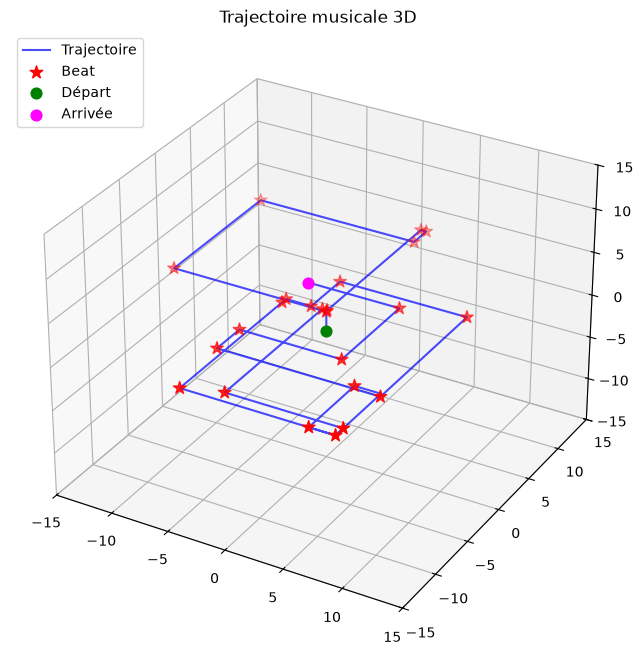

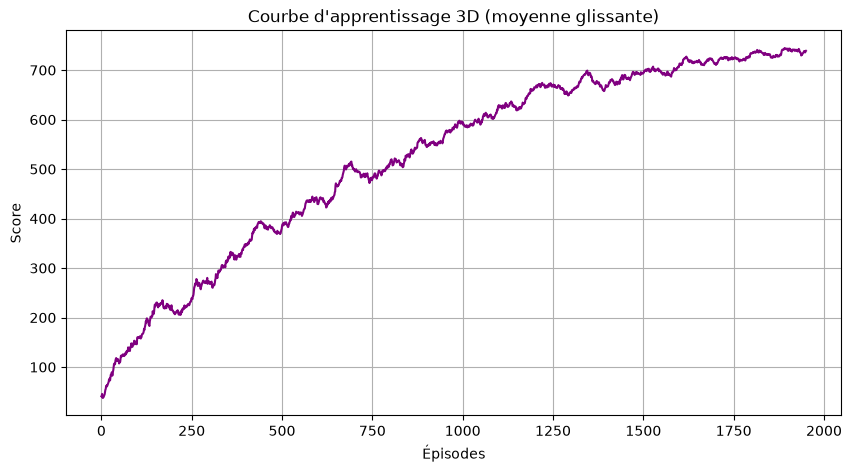

In [42]:
import torch.optim as optim
 
env = MusicArena3D()
agent = PPOAgent(state_dim=env.state_dim, n_actions=env.n_actions)
optimizer = optim.Adam(agent.parameters(), lr=3e-4)
memory = PPOMemory()
 
max_episodes = 2000
update_timestep = 2500
tc = 0
scores = []
 
print("Entraînement 3D...")
for episode in range(1, max_episodes + 1):
    state = env.reset(); sc, done = 0.0, False
    while not done:
        tc += 1
        a, lp, v = agent.act(state)
        ns, r, done = env.step(a)
        memory.states.append(state); memory.actions.append(a); memory.logprobs.append(lp)
        memory.values.append(v); memory.rewards.append(r); memory.dones.append(done)
        state = ns; sc += r
        if tc % update_timestep == 0:
            ppo_update(agent, optimizer, memory); memory.clear()
    scores.append(sc)
    if episode % 100 == 0:
        print(f"Ep {episode}/{max_episodes} | score moyen : {np.mean(scores[-100:]):.1f}")
 
 
def cover3d(env, ng=4):
    g = set()
    for p in env.history:
        c = tuple(min(max(int((v + env.room_size) / (2 * env.room_size) * ng), 0), ng - 1) for v in p)
        g.add(c)
    return len(g), ng ** 3
 
state = env.reset(); done = False; ok = tot = walls = 0
while not done:
    k = env.current_step + 1; is_b = env._beat(k) >= 0.5
    with torch.no_grad():
        a = int(torch.argmax(agent.actor(torch.FloatTensor(state).unsqueeze(0))).item())
    state, _, done = env.step(a)
    if is_b:
        tot += 1
        if a != 0: ok += 1
    if np.any(np.abs(env.pos) >= env.room_size): walls += 1
c, tot_c = cover3d(env)
print(f"Éval : beats {ok}/{tot} ({100*ok/max(tot,1):.0f}%) | murs {walls} | couverture {c}/{tot_c}")
env.render()
 
w = 50
ma = np.convolve(scores, np.ones(w) / w, mode="valid")
plt.figure(figsize=(10, 5)); plt.plot(ma, color="purple")
plt.title("Courbe d'apprentissage 3D (moyenne glissante)")
plt.xlabel("Épisodes"); plt.ylabel("Score"); plt.grid(True); plt.show()
 
